In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('car_sales_new.csv')
df.head(25)

,car,price,body,mileage,engV,engType,registration,year,model,drive
0,Ford,15500.000,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.000,sedan,173,1.8,Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000.000,other,135,5.5,Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800.000,van,162,1.8,Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000.000,vagon,91,NaN,Other,yes,2013,E-Class,NaN
5,Nissan,16600.000,crossover,83,2.0,Petrol,yes,2013,X-Trail,full
6,Honda,6500.000,sedan,199,2.0,Petrol,yes,2003,Accord,front
7,Renault,10500.000,vagon,185,1.5,Diesel,yes,2011,Megane,front
8,Mercedes-Benz,21500.000,sedan,146,1.8,Gas,yes,2012,E-Class,rear
9,Mercedes-Benz,22700.000,sedan,125,2.2,Diesel,yes,2010,E-Class,rear


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car           9576 non-null   str    
 1   price         9576 non-null   float64
 2   body          9576 non-null   str    
 3   mileage       9576 non-null   int64  
 4   engV          9142 non-null   float64
 5   engType       9576 non-null   str    
 6   registration  9576 non-null   str    
 7   year          9576 non-null   int64  
 8   model         9576 non-null   str    
 9   drive         9065 non-null   str    
dtypes: float64(2), int64(2), str(6)
memory usage: 748.3 KB


In [4]:
df.isnull().sum()

car               0
price             0
body              0
mileage           0
engV            434
engType           0
registration      0
year              0
model             0
drive           511
dtype: int64

In [5]:
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
percent

drive           0.053363
engV            0.045322
price           0.000000
car             0.000000
mileage         0.000000
body            0.000000
engType         0.000000
registration    0.000000
year            0.000000
model           0.000000
dtype: float64

In [6]:
df.describe()

,price,mileage,engV,year
count,9576.000000,9576.000000,9142.000000,9576.000000
mean,15633.317316,138.862364,2.646344,2006.605994
std,24106.523436,98.629754,5.927699,7.067924
min,0.000000,0.000000,0.100000,1953.000000
25%,4999.000000,70.000000,1.600000,2004.000000
50%,9200.000000,128.000000,2.000000,2008.000000
75%,16700.000000,194.000000,2.500000,2012.000000
max,547800.000000,999.000000,99.990000,2016.000000


In [7]:
print("How many values are 0? : ", df.price[df.price == 0].count())

How many values are 0? :  267


In [8]:
print("How many values are 0? : ", df.mileage[df.mileage == 0])

How many values are 0? :  10      0
17      0
20      0
21      0
24      0
       ..
9234    0
9268    0
9382    0
9483    0
9484    0
Name: mileage, Length: 348, dtype: int64


In [9]:
# Lowercase all column names for consistency.
# Converting the map iterator to a list is the safe form — assigning the
# raw map object relies on pandas silently consuming iterators.
df.columns = list(map(str.lower, df.columns))
df.dtypes

car                 str
price           float64
body                str
mileage           int64
engv            float64
engtype             str
registration        str
year              int64
model               str
drive               str
dtype: object

In [10]:
df.head(25)

,car,price,body,mileage,engv,engtype,registration,year,model,drive
0,Ford,15500.000,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.000,sedan,173,1.8,Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000.000,other,135,5.5,Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800.000,van,162,1.8,Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000.000,vagon,91,NaN,Other,yes,2013,E-Class,NaN
5,Nissan,16600.000,crossover,83,2.0,Petrol,yes,2013,X-Trail,full
6,Honda,6500.000,sedan,199,2.0,Petrol,yes,2003,Accord,front
7,Renault,10500.000,vagon,185,1.5,Diesel,yes,2011,Megane,front
8,Mercedes-Benz,21500.000,sedan,146,1.8,Gas,yes,2012,E-Class,rear
9,Mercedes-Benz,22700.000,sedan,125,2.2,Diesel,yes,2010,E-Class,rear


In [11]:
df['drive'] = df['drive'].fillna("UnSpecified")
df.drive.unique()

<StringArray>
['full', 'rear', 'front', 'UnSpecified']
Length: 4, dtype: str

In [12]:
df['engv'].fillna((df['engv'].mean()), inplace=True)

C:\Users\aziz1\AppData\Local\Temp\ipykernel_3100\4226208166.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['engv'].fillna((df['engv'].mean()), inplace=True)


0       2.500000
1       1.800000
2       5.500000
3       1.800000
4       2.646344
          ...   
9571    2.000000
9572    1.600000
9573    3.500000
9574    3.500000
9575    3.600000
Name: engv, Length: 9576, dtype: float64

In [13]:
df['price'] = df['price'].replace(0, df['price'].mean())

In [14]:
mileage_avg = sum(df['mileage']) / len(df['mileage'])
df['mileage_level'] = ["high mileage" if i > mileage_avg else "low mileage" for i in df['mileage']]
df.loc[:10]

,car,price,body,mileage,engv,engtype,registration,year,model,drive,mileage_level
0,Ford,15500.000,crossover,68,2.5,Gas,yes,2010,Kuga,full,low mileage
1,Mercedes-Benz,20500.000,sedan,173,1.8,Gas,yes,2011,E-Class,rear,high mileage
2,Mercedes-Benz,35000.000,other,135,5.5,Petrol,yes,2008,CL 550,rear,low mileage
3,Mercedes-Benz,17800.000,van,162,1.8,Diesel,yes,2012,B 180,front,high mileage
4,Mercedes-Benz,33000.000,vagon,91,NaN,Other,yes,2013,E-Class,UnSpecified,low mileage
5,Nissan,16600.000,crossover,83,2.0,Petrol,yes,2013,X-Trail,full,low mileage
6,Honda,6500.000,sedan,199,2.0,Petrol,yes,2003,Accord,front,high mileage
7,Renault,10500.000,vagon,185,1.5,Diesel,yes,2011,Megane,front,high mileage
8,Mercedes-Benz,21500.000,sedan,146,1.8,Gas,yes,2012,E-Class,rear,high mileage
9,Mercedes-Benz,22700.000,sedan,125,2.2,Diesel,yes,2010,E-Class,rear,low mileage


<Axes: xlabel='year'>

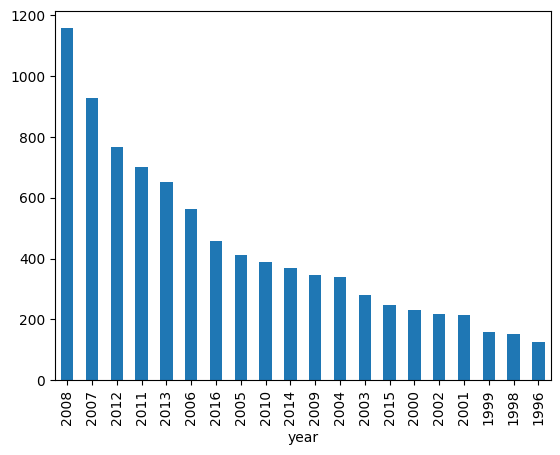

In [15]:
df['year'].value_counts().head(20).plot.bar()

<Axes: xlabel='body'>

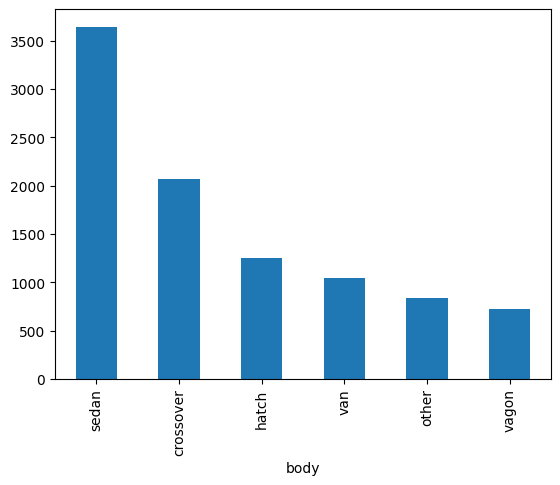

In [16]:
df['body'].value_counts().head(20).plot.bar()

<Axes: xlabel='car'>

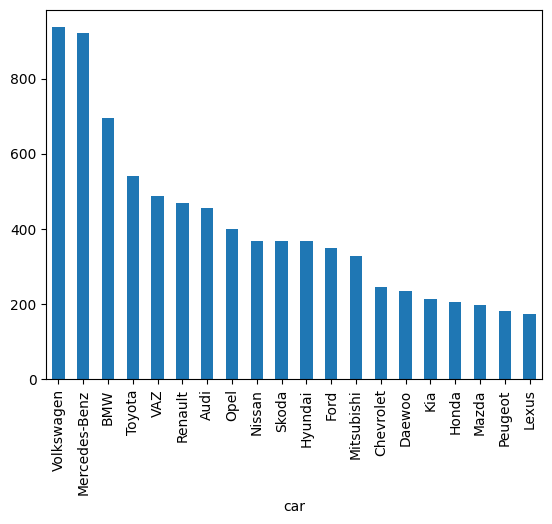

In [17]:
df['car'].value_counts().head(20).plot.bar()

C:\Users\aziz1\AppData\Local\Temp\ipykernel_3100\716133650.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_model.iloc[:, 0],


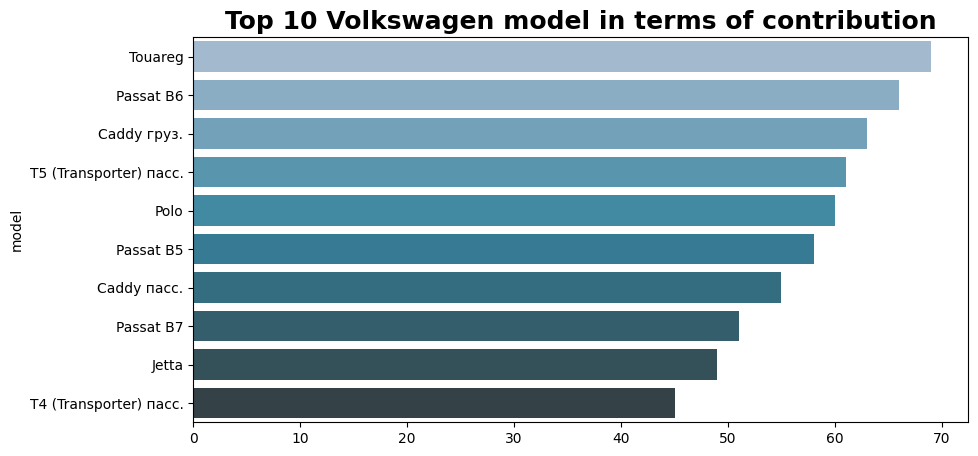

In [18]:
usa = df.loc[df['car'] == 'Volkswagen']
top_10_model = usa['model'].value_counts()[:10].to_frame()
plt.figure(figsize=(10, 5))

# In pandas >= 2.0, value_counts().to_frame() names its single column 'count'
# (in older pandas it was named after the Series). Reference the first column
# positionally so the code works on both.
sns.barplot(x=top_10_model.iloc[:, 0],
            y=top_10_model.index,
            palette='PuBuGn_d')
plt.title('Top 10 Volkswagen model in terms of contribution',
          fontsize=18, fontweight='bold')
plt.xlabel('')
plt.show()

C:\Users\aziz1\AppData\Local\Temp\ipykernel_3100\4254265438.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_eng.iloc[:, 0],


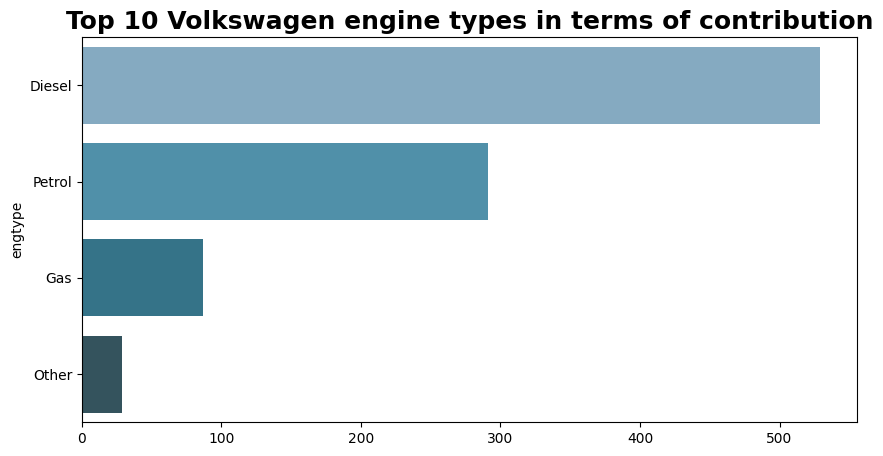

In [19]:
usa = df.loc[df['car'] == 'Volkswagen']
top_10_eng = usa['engtype'].value_counts()[:10].to_frame()
plt.figure(figsize=(10, 5))

# Same pandas-2.0 fix as the previous cell.
sns.barplot(x=top_10_eng.iloc[:, 0],
            y=top_10_eng.index,
            palette='PuBuGn_d')
plt.title('Top 10 Volkswagen engine types in terms of contribution',
          fontsize=18, fontweight='bold')
plt.xlabel('')
plt.show()

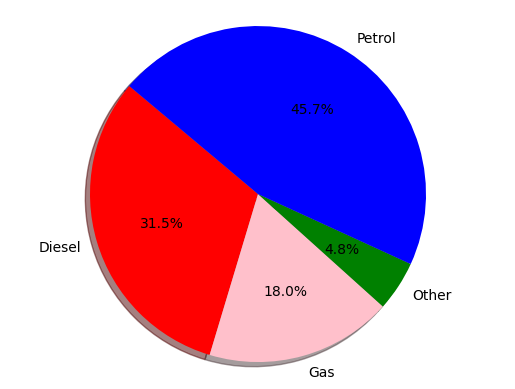

In [20]:
# Use Series.value_counts() directly — pd.value_counts() is deprecated
# and emits a FutureWarning in modern pandas.
ct = df['engtype'].value_counts(sort=False).sort_index()
labels = list(ct.index)
sizes = ct.values
colors = ['red', 'pink', 'green', 'blue']
plt.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # keeps the pie circular
plt.show()

<Axes: xlabel='mileage', ylabel='price'>

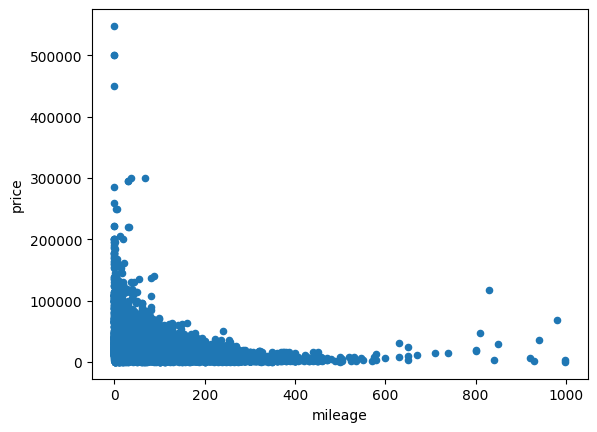

In [21]:
df.plot.scatter(x = 'mileage', y = 'price')

<Axes: xlabel='mileage', ylabel='price'>

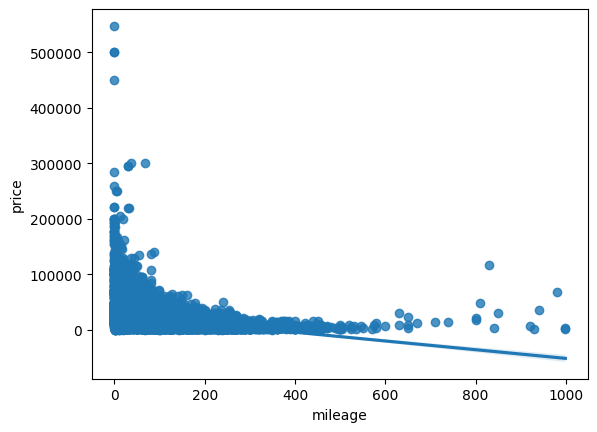

In [22]:
sns.regplot(x='mileage', y='price', data=df)

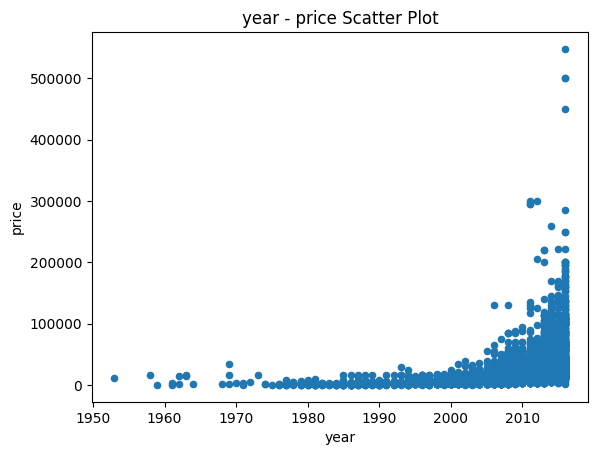

In [23]:
df.plot(kind = 'scatter', x='year', y = 'price')
plt.xlabel("year")
plt.ylabel("price")
plt.title("year - price Scatter Plot")
plt.show()

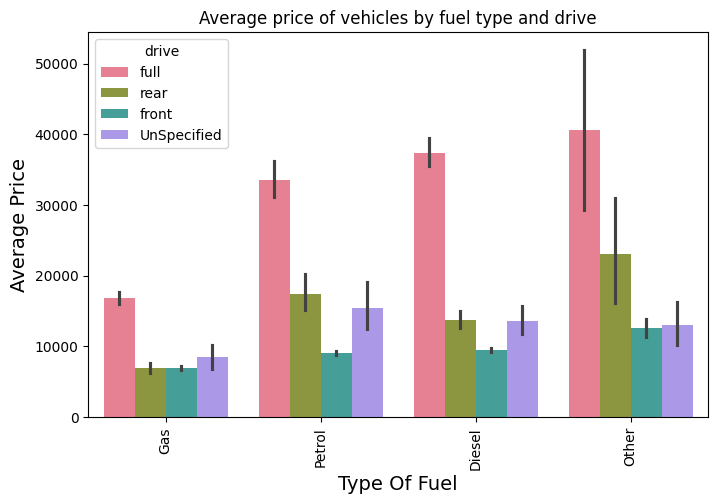

In [24]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(x="engtype", y="price", hue= "drive", palette="husl", data=df)
ax.set_title("Average price of vehicles by fuel type and drive",fontdict= {'size':12})
ax.xaxis.set_label_text("Type Of Fuel",fontdict= {'size':14})
ax.yaxis.set_label_text("Average Price",fontdict= {'size':14})
ticks = plt.setp(ax.get_xticklabels(),rotation=90)
plt.show()

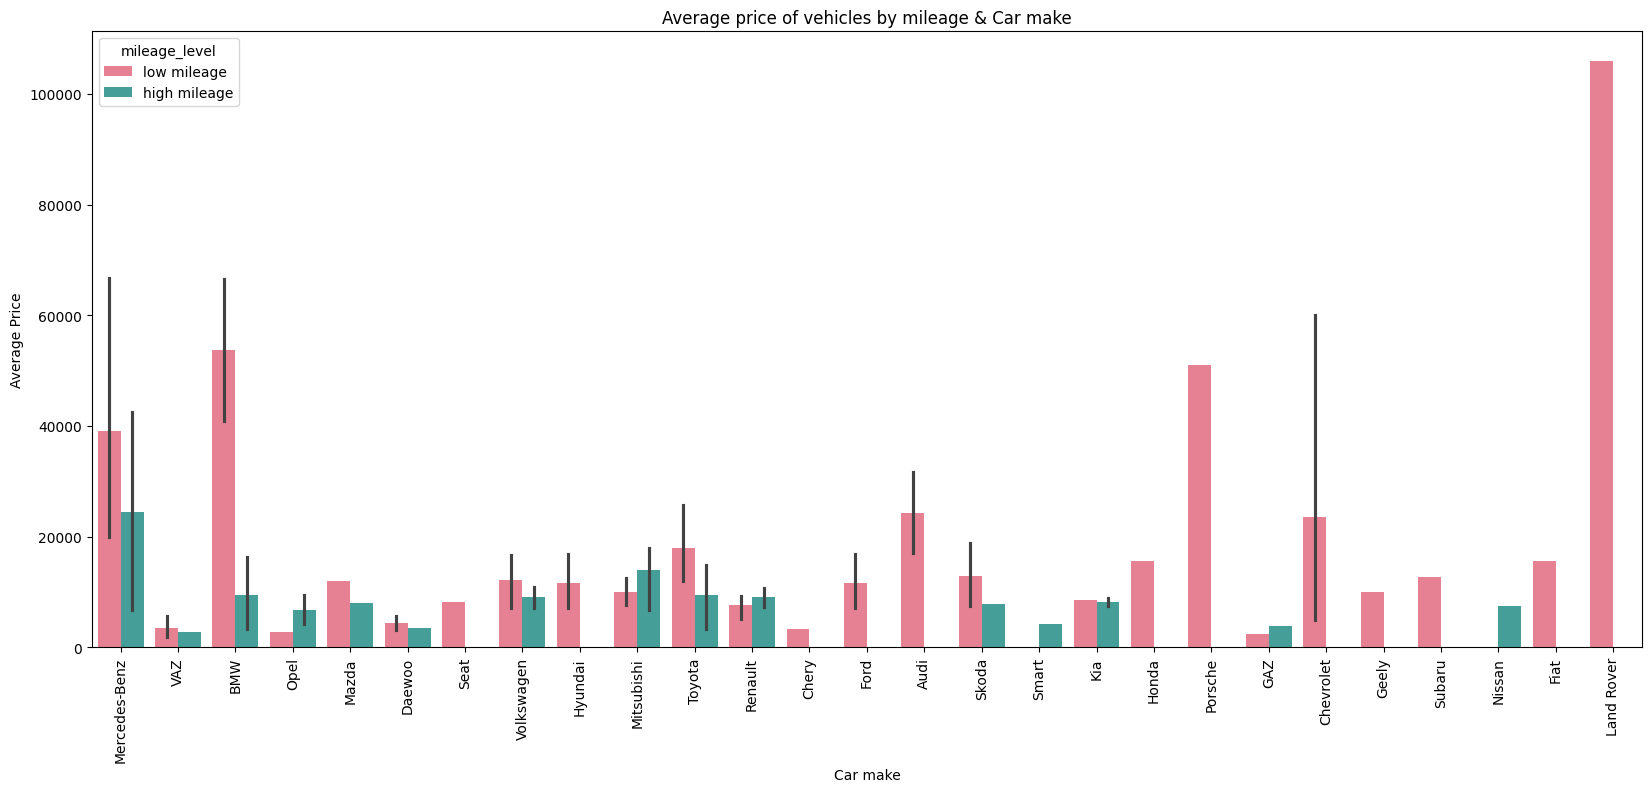

In [25]:
fig, ax = plt.subplots(figsize=(20,8))

Carsales_Sample = df.sample(100)
sns.barplot(x="car", y="price", hue= "mileage_level", palette="husl",data=Carsales_Sample)
ax.set_title("Average price of vehicles by mileage & Car make",fontdict= {'size':12})
ax.xaxis.set_label_text("Car make",fontdict= {'size':10})
ax.yaxis.set_label_text("Average Price",fontdict= {'size':10})
ticks = plt.setp(ax.get_xticklabels(),rotation=90)
plt.show()

In [27]:
corr = df.select_dtypes(include='number').corr(method='pearson')
corr

,price,mileage,engv,year
price,1.000000,-0.323532,0.053234,0.380048
mileage,-0.323532,1.000000,0.047070,-0.495599
engv,0.053234,0.047070,1.000000,-0.042251
year,0.380048,-0.495599,-0.042251,1.000000


<Axes: >

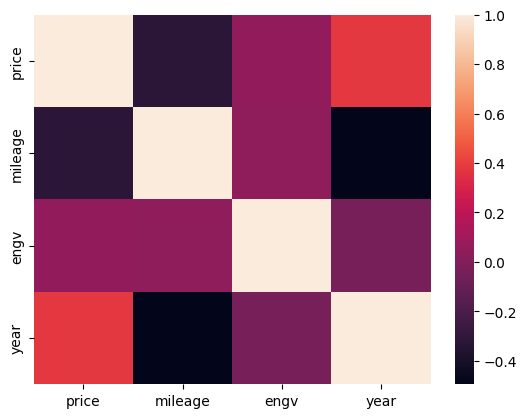

In [28]:
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns)